# 01 — Exploration du jeu de données (IRM cérébrales)
Objectif : comprendre la structure du dataset, convertir les labels en **binaire** (tumeur vs non‑tumeur), vérifier la qualité des fichiers et analyser les résolutions d’images.

**Dataset** : `sartajbhuvaji/brain-tumor-classification-mri` (Kaggle).

## 1) Imports et configuration
- `pathlib` : parcours des dossiers
- `PIL` : ouverture d’images
- `matplotlib` : affichage
- `Counter` : comptage des classes


In [1]:
from pathlib import Path
from collections import Counter
import random

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


## 2) Chemins des données
On suppose que le dataset est copié dans : `data/raw/brain_mri/`.

Structure attendue :
```
data/raw/brain_mri/
  Training/
    glioma_tumor/
    meningioma_tumor/
    pituitary_tumor/
    no_tumor/
  Testing/
    ... (mêmes classes)
```

In [2]:
train_dir = Path("data/raw/brain_mri/Training")
test_dir  = Path("data/raw/brain_mri/Testing")

train_dir.exists(), test_dir.exists()


(True, True)

## 3) Conversion multi‑classe → binaire (tumeur vs non‑tumeur)
- **0** = `no_tumor`
- **1** = tout le reste (`glioma_tumor`, `meningioma_tumor`, `pituitary_tumor`)

On construit une liste `items` de tuples `(chemin_image, label_binaire)`.

In [3]:
items = []

for cls_dir in train_dir.iterdir():
    if not cls_dir.is_dir():
        continue

    label = 0 if cls_dir.name == "no_tumor" else 1

    for img_path in cls_dir.glob("*"):
        if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            items.append((str(img_path), label))

len(items), items[:3]


(2870,
 [('data/raw/brain_mri/Training/no_tumor/image(272).jpg', 0),
  ('data/raw/brain_mri/Training/no_tumor/image(60).jpg', 0),
  ('data/raw/brain_mri/Training/no_tumor/image(39).jpg', 0)])

## 4) Distribution des classes (binaire)
On vérifie l’équilibre (ou le déséquilibre) entre `no_tumor` et `tumor`.

In [4]:
counts = Counter([label for _, label in items])
counts


Counter({1: 2475, 0: 395})

### Pourquoi tu vois souvent des tumeurs dans l’échantillon ?
Si tu observes `Counter({1: 2475, 0: 395})`, c’est **normal** :
- le dataset est **très déséquilibré** (beaucoup plus d’images « tumeur »).
- donc `random.sample(items, 6)` retourne souvent des images label **1**.

Pour afficher un échantillon plus représentatif, on échantillonne **par classe**.

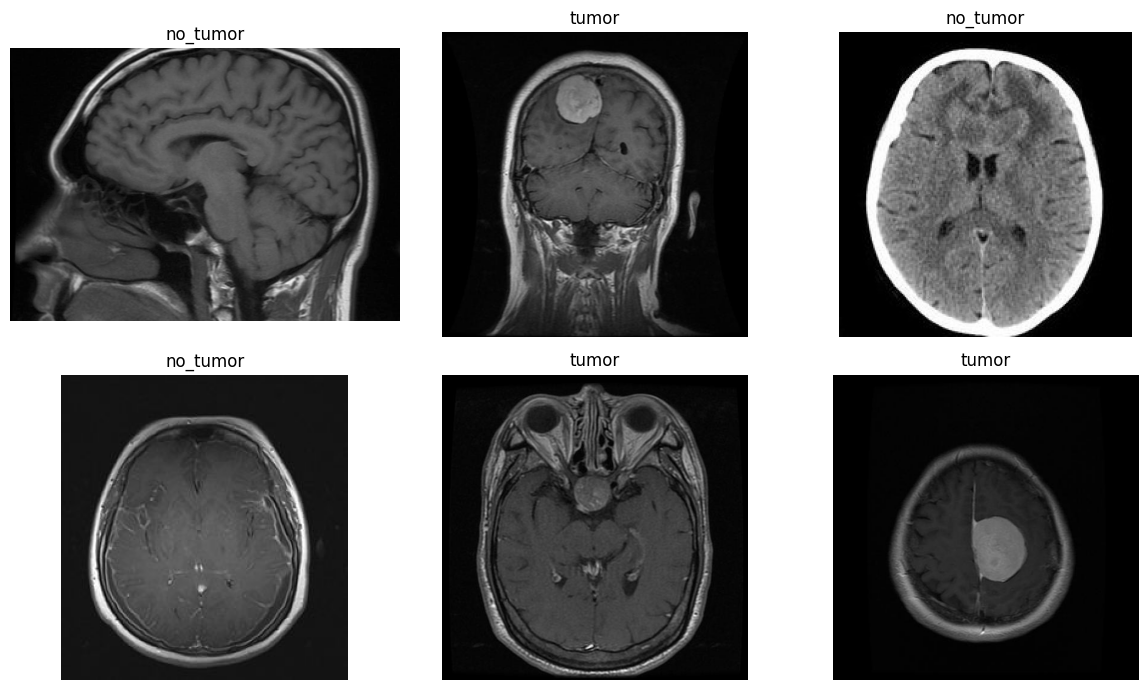

In [5]:
items_0 = [x for x in items if x[1] == 0]
items_1 = [x for x in items if x[1] == 1]

sample = random.sample(items_0, k=min(3, len(items_0))) + random.sample(items_1, k=min(3, len(items_1)))
random.shuffle(sample)

plt.figure(figsize=(12, 7))
for i, (path, label) in enumerate(sample):
    img = Image.open(path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title("no_tumor" if label == 0 else "tumor")
    plt.axis("off")
plt.tight_layout()
plt.show()


## 5) Vérification qualité : images corrompues, modes, tailles
On collecte :
- `img.mode` (RGB, L…)
- `img.size` = (largeur, hauteur)
- `bad` = nb d’images illisibles (exceptions)

In [6]:
sizes = []
modes = Counter()
bad = 0

for path, label in items:
    try:
        img = Image.open(path)
        sizes.append(img.size)  # (w, h)
        modes[img.mode] += 1
    except Exception:
        bad += 1

bad, modes, sizes[:3]


(0, Counter({'RGB': 2870}), [(278, 253), (236, 236), (236, 257)])

## 6) Résolutions : min / max + percentiles
Utile pour décider d’un `Resize` (ex: 256×256) dans les transformations PyTorch.

In [7]:
widths  = [w for w, h in sizes]
heights = [h for w, h in sizes]

print("min width:", min(widths))
print("max width:", max(widths))
print("min height:", min(heights))
print("max height:", max(heights))


min width: 180
max width: 1375
min height: 198
max height: 1446


In [8]:
np.percentile(widths,  [0, 25, 50, 75, 100]), np.percentile(heights, [0, 25, 50, 75, 100])


(array([ 180.,  512.,  512.,  512., 1375.]),
 array([ 198.,  512.,  512.,  512., 1446.]))

### Lecture des percentiles
Si les percentiles 25/50/75 valent **512**, c’est que **la majorité** des images sont en 512×512.

Pour la **Phase 1 (classification)** : `Resize(256,256)` est un bon compromis vitesse/détails.
Le `Resize` doit rester dans les `transforms` au moment du `Dataset`/`DataLoader`.

## 7)  Vérification rapide du dossier Testing

In [9]:
test_items = []

for cls_dir in test_dir.iterdir():
    if not cls_dir.is_dir():
        continue
    label = 0 if cls_dir.name == "no_tumor" else 1
    for img_path in cls_dir.glob("*"):
        if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            test_items.append((str(img_path), label))

len(test_items), Counter([y for _, y in test_items])


(394, Counter({1: 289, 0: 105}))

## 8) Prochaines étapes 
1. `Dataset` PyTorch + `DataLoader`
2. `transforms`: Resize + Normalize (et augmentations)
3. Split `train/val` (stratifié)
4. Baseline modèle (ex: ResNet18)
5. Métriques adaptées au déséquilibre : F1, recall, ROC-AUC
